<h1 align="center">Machine Learning</h1>
    <h2 align="center">SVM</h2>
    <h3 align="center">Zahra Amini</h3>
<div style="width: 100%; text-align: center;">
    <table>
        <tr>
            <td>
                <a class="link" href="https://t.me/Zahraamini_ai">Telegram</a><br>
                <a class="link" href="https://www.linkedin.com/in/zahraamini-ai/">LinkedIn</a><br>
                <a class="link" href="https://www.youtube.com/@AcademyHobot">YouTube</a><br>
            </td>
            <td>
                <a class="link" href="https://github.com/aminizahra">GitHub</a><br>
                <a class="link" href="https://www.kaggle.com/aminizahra">Kaggle</a><br>
                <a class="link" href="https://www.instagram.com/zahraamini_ai/">Instagram</a><br>
            </td>
        </tr>
    </table>
</div>

### Linear Kernel:
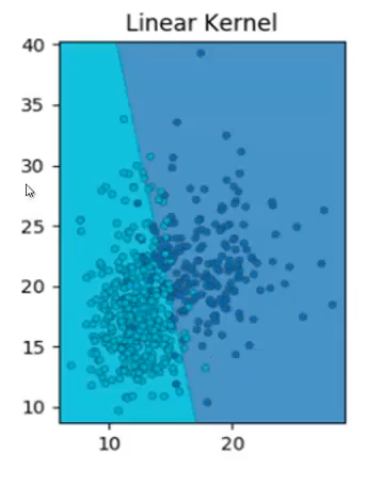

### Gaussian / RBF kernel:
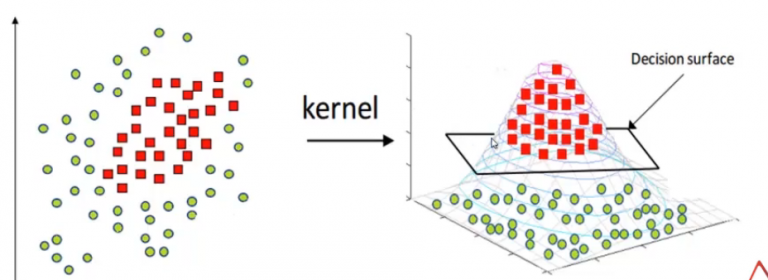

### Polynomial kernel:
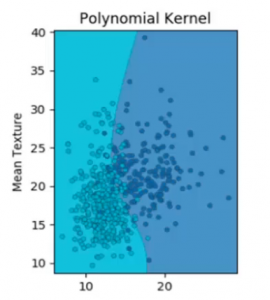

* But the problem with the polynomial kernel is, the number of higher dimension features increases exponentially. As a result, this is computationally more expensive than RBF or linear kernel.

# 0. Import libraries

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report #,plot_confusion_matrix, 
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from joblib import dump, load
import warnings
warnings.filterwarnings('ignore')

In [65]:
from sklearn.metrics import ConfusionMatrixDisplay

# 1.Import dataset

In [5]:
diabetes_df = pd.read_csv('diabetes.csv')

In [7]:
diabetes_df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [9]:
diabetes_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [13]:
diabetes_df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In this particular dataset all the missing values were given the 0 as a value which is not good for the authenticity of the dataset. Hence we will first replace the 0 value with the NAN value then start the imputation process.

* If only a few rows are missing some values, then it might just be a good idea to drop those rows.
* We choose a threshold of 1%. It means, if there is less than 1% of a feature are missing,then we will consider just dropping that rows.

### Dropping Rows:

- Infant = 0-1 year.
- Toddler = 2-4 yrs.
- Child = 5-12 yrs.
- Teen = 13-19 yrs.
- Adult = 20-39 yrs.
- Middle Age Adult = 40-59 yrs.
- Senior Adult = 60+

# 2. train test split

In [17]:
X = diabetes_df.drop('Outcome', axis=1)

In [19]:
y= diabetes_df['Outcome']

In [21]:
X.shape

(768, 8)

In [23]:
y.shape

(768,)

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [27]:
X_train.shape

(614, 8)

# 3. Feature Scaling

In [29]:
scaler = StandardScaler()

In [31]:
X_train_scaled = scaler.fit_transform(X_train)

In [33]:
X_test_scaled = scaler.transform(X_test)

In [35]:
X_test_scaled

array([[ 0.68185612, -0.71402038, -0.61712658, ...,  0.26073561,
        -0.11637247,  0.87809089],
       [-0.52639686, -0.27664283,  0.30191569, ...,  0.48053518,
        -0.954231  , -1.03594038],
       [-0.52639686, -0.40160784, -0.29275872, ..., -0.15300476,
        -0.9245197 , -1.03594038],
       ...,
       [ 1.28598261, -0.80774414,  0.13973176, ...,  0.62275843,
         0.04703966,  2.0961108 ],
       [-0.52639686,  0.78555979,  0.03160914, ..., -0.51502758,
        -0.39268751, -0.33992901],
       [ 1.28598261, -1.46381046,  0.03160914, ...,  0.42881763,
         0.70068816,  0.53008521]])

# 4. Run SVM with default hyperparameters

In [37]:
def svm_model(X_train, y_train, C=1.0, kernel='rbf', degree=3, gamma='scale'):
    svm = SVC(C=C, kernel=kernel, degree=degree, gamma=gamma)
    svm.fit(X_train, y_train)
    return svm

In [39]:
rbf_svm = svm_model(X_train_scaled, y_train)

In [41]:
def model_evaluation(model, X_test, y_test):
    y_pred = model.predict(X_test)
    print(accuracy_score(y_test, y_pred))
    return y_pred

In [43]:
rbf_y_pred = model_evaluation(rbf_svm, X_test_scaled, y_test)

0.7337662337662337


In [45]:
rbf_y_pred

array([0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0,
       0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0,
       0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1,
       0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1,
       0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
      dtype=int64)

### Run SVM with rbf kernel and C=100.0

In [47]:
rbf_svm = svm_model(X_train_scaled, y_train, C=100)

In [49]:
rbf_y_pred = model_evaluation(rbf_svm, X_test_scaled, y_test)

0.6818181818181818


### Run SVM with rbf kernel and C=1000.0


# 5. Run SVM with linear kernel


### Run SVM with linear kernel and C=1.0

In [51]:
linear_svm = svm_model(X_train_scaled, y_train, C=1.0, kernel='linear')

In [53]:
linear_y_pred = model_evaluation(linear_svm, X_test_scaled, y_test)

0.7597402597402597


### Run SVM with linear kernel and C=100.0

### Run SVM with linear kernel and C=1000.0

### Compare the train-set and test-set accuracy


### Check for overfitting and underfitting

In [55]:
y_train_pred = model_evaluation(linear_svm, X_train_scaled, y_train)

y_test_pred = model_evaluation(linear_svm, X_test_scaled, y_test)

0.7719869706840391
0.7597402597402597


In [57]:
0.7719869706840391 - 0.7597402597402597

0.012246710943779382

# 6. Run SVM with polynomial kernel


### Run SVM with polynomial kernel and C=1.0

In [59]:
poly_svm = svm_model(X_train_scaled, y_train, C=1.0, kernel='poly')

In [61]:
poly_y_pred = model_evaluation(poly_svm, X_test_scaled, y_test)

0.7467532467532467


 ### Run SVM with polynomial kernel and C=100.0

# 7. Run SVM with sigmoid kernel


### Run SVM with sigmoid kernel and C=1.0

### Run SVM with sigmoid kernel and C=100.0

# 8. Confusion matrix

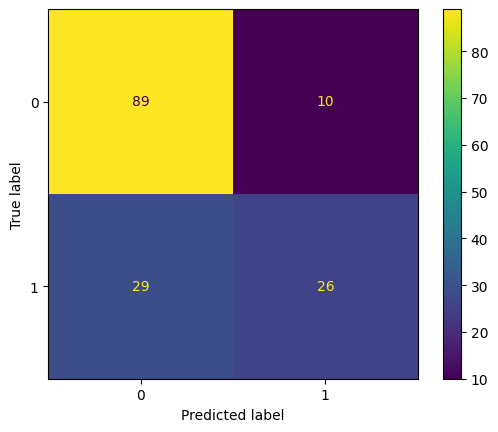

In [67]:
ConfusionMatrixDisplay.from_estimator(poly_svm,X_test_scaled,y_test)

# 9. Classification metrices

In [69]:
print(classification_report(y_test, poly_y_pred))

              precision    recall  f1-score   support

           0       0.75      0.90      0.82        99
           1       0.72      0.47      0.57        55

    accuracy                           0.75       154
   macro avg       0.74      0.69      0.70       154
weighted avg       0.74      0.75      0.73       154



# 10. k-fold Cross Validation

### k-Fold Cross Validation with shuffle split with  linear kernel

In [71]:
pipe = Pipeline([
        ('scale', StandardScaler()),
        ('clf', SVC(kernel='linear'))])

In [73]:
k_fold = KFold(n_splits=5, shuffle=True, random_state=42)

In [75]:
linear_scores = cross_val_score(pipe, X, y, cv=k_fold)

In [77]:
linear_scores

array([0.75974026, 0.77272727, 0.74675325, 0.79084967, 0.73202614])

In [79]:
linear_scores.mean()

0.7604193192428486

### k-Fold Cross Validation with shuffle split with rbf kernel

# 11. Hyperparameter Optimization using GridSearch CV

In [81]:
pipe = Pipeline([
        ('scale', StandardScaler()),
        ('clf', SVC())])

In [83]:
parameters = [ dict(clf__C=[1, 10, 100, 1000], clf__kernel=['linear']),
               dict(clf__C=[1, 10, 100, 1000], clf__kernel=['rbf'], clf__gamma=[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]),
               dict(clf__C=[1, 10, 100, 1000], clf__kernel=['poly'], clf__degree= [2,3,4] ,clf__gamma=[0.01,0.02,0.03,0.04,0.05]) 
              ]

In [85]:
grid_search = GridSearchCV(estimator = pipe,  
                           param_grid = parameters,
                           scoring = 'accuracy',
                           cv = 5,
                           verbose=3)

In [87]:
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 100 candidates, totalling 500 fits
[CV 1/5] END ......clf__C=1, clf__kernel=linear;, score=0.756 total time=   0.0s
[CV 2/5] END ......clf__C=1, clf__kernel=linear;, score=0.805 total time=   0.0s
[CV 3/5] END ......clf__C=1, clf__kernel=linear;, score=0.748 total time=   0.0s
[CV 4/5] END ......clf__C=1, clf__kernel=linear;, score=0.732 total time=   0.0s
[CV 5/5] END ......clf__C=1, clf__kernel=linear;, score=0.770 total time=   0.0s
[CV 1/5] END .....clf__C=10, clf__kernel=linear;, score=0.756 total time=   0.0s
[CV 2/5] END .....clf__C=10, clf__kernel=linear;, score=0.813 total time=   0.0s
[CV 3/5] END .....clf__C=10, clf__kernel=linear;, score=0.748 total time=   0.0s
[CV 4/5] END .....clf__C=10, clf__kernel=linear;, score=0.732 total time=   0.0s
[CV 5/5] END .....clf__C=10, clf__kernel=linear;, score=0.770 total time=   0.0s
[CV 1/5] END ....clf__C=100, clf__kernel=linear;, score=0.756 total time=   0.2s
[CV 2/5] END ....clf__C=100, clf__kernel=linea

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scale', StandardScaler()),
                                       ('clf', SVC())]),
             param_grid=[{'clf__C': [1, 10, 100, 1000],
                          'clf__kernel': ['linear']},
                         {'clf__C': [1, 10, 100, 1000],
                          'clf__gamma': [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8,
                                         0.9],
                          'clf__kernel': ['rbf']},
                         {'clf__C': [1, 10, 100, 1000],
                          'clf__degree': [2, 3, 4],
                          'clf__gamma': [0.01, 0.02, 0.03, 0.04, 0.05],
                          'clf__kernel': ['poly']}],
             scoring='accuracy', verbose=3)

In [89]:
grid_search.best_params_

{'clf__C': 1, 'clf__gamma': 0.2, 'clf__kernel': 'rbf'}

In [91]:
grid_search.best_score_

0.7769292283086766

# 11. Hyperparameter Optimization using GridSearch CV

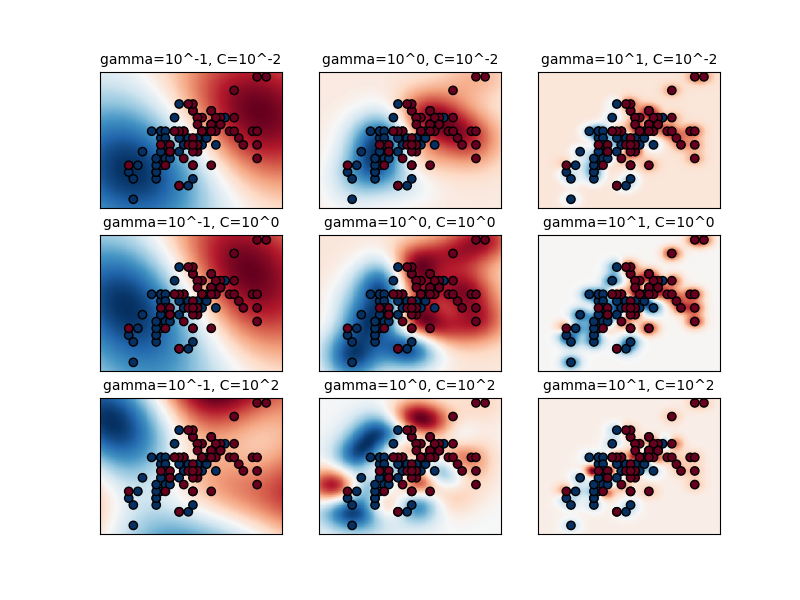

# Finished